In [1]:
from datasets import load_dataset
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:

# Load only specific columns
particles = load_dataset(
    "CERN/ColliderML-Release-1",
    "ttbar_pu0_calo_hits",
    split="train",
    
    streaming=True, 
)




Resolving data files:   0%|          | 0/100 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/1000 [00:00<?, ?it/s]

In [3]:
NUM_EVENTS = 1000

event_multiplicity = []

energies, x, y, z, detector = {}, {}, {}, {}, {}

for i, event in enumerate(tqdm(particles, total=NUM_EVENTS)):
    if i >= NUM_EVENTS:
        break
    event_multiplicity.append(len(event["x"]))
    energies[i] = event["total_energy"]
    x[i] = event["x"]
    y[i] = event["y"]
    z[i] = event["z"]
    detector[i] = event["detector"]


100%|██████████| 1000/1000 [06:32<00:00,  2.55it/s]


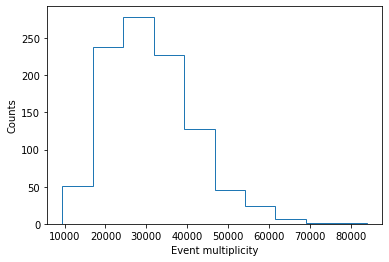

In [4]:
plt.figure()
plt.hist(event_multiplicity, histtype = "step")
plt.xlabel("Event multiplicity")
plt.ylabel("Counts")
plt.show()

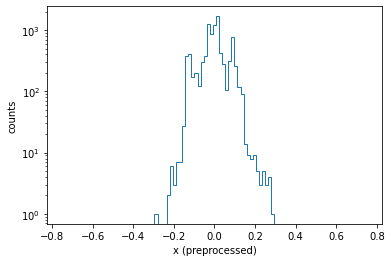

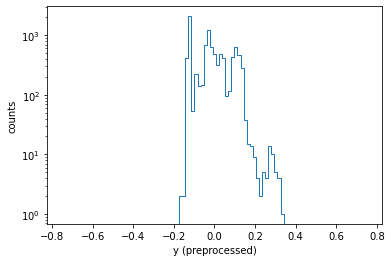

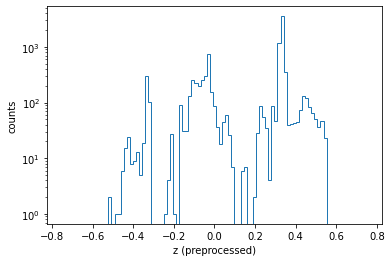

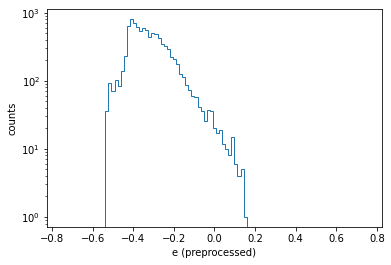

In [12]:
loc_x = np.array(x[0]) / 1e4
loc_y = np.array(y[0]) / 1e4
loc_z = np.array(z[0]) / 1e4
loc_e = np.log(np.array(energies[0]) * 1e2) / 10 

NUM_BINS = 100
BIN_BOUND = 0.75

plt.figure()
plt.hist(loc_x, bins = np.linspace(-BIN_BOUND, BIN_BOUND, NUM_BINS), histtype = "step")
plt.xlabel("x (preprocessed)")
plt.ylabel("counts")
plt.yscale("log")
plt.show()

plt.figure()
plt.hist(loc_y, bins = np.linspace(-BIN_BOUND, BIN_BOUND, NUM_BINS), histtype = "step")
plt.xlabel("y (preprocessed)")
plt.ylabel("counts")
plt.yscale("log")
plt.show()

plt.figure()
plt.hist(loc_z, bins = np.linspace(-BIN_BOUND, BIN_BOUND, NUM_BINS), histtype = "step")
plt.xlabel("z (preprocessed)")
plt.ylabel("counts")
plt.yscale("log")
plt.show()

plt.figure()
plt.hist(loc_e, bins = np.linspace(-BIN_BOUND, BIN_BOUND, NUM_BINS), histtype = "step")
plt.xlabel("e (preprocessed)")
plt.ylabel("counts")
plt.yscale("log")
plt.show()